# Driver Feedback Analysis

## Topic Modeling using BERTopic

This notebook performs topic modeling on passenger feedback using BERTopic. Unlike sentiment analysis, which identifies whether a review expresses a positive, neutral, or negative opinion, topic modeling discovers the underlying themes discussed by passengers. These themes provide insights into recurring issues and experiences such as driver behavior, vehicle condition, traffic, fare concerns, and ride quality.

## Import libraries

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import umap

from utils.config import (
    PROCESSED_DATA_DIR,
    MODEL_DIR
)

from utils.data_loader import (
    load_processed_feedback,
    save_processed_feedback
)

from utils.constants import (
    MIN_TOPIC_SIZE,
    NR_TOPICS
)

from utils.topic_utils import (
    load_embedding_model,
    train_topic_model,
    get_topic_info
)

from utils.model_utils import save_topic_model

from utils.visualization import plot_topic_distribution
from bertopic import BERTopic

I0000 00:00:1784716971.942861   90872 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784716971.943694   90872 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784716972.024238   90872 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784716974.070928   90872 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Load Dataset

In [3]:
df = load_processed_feedback()

df.head()

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
0,TR000001,2025-12-26 12:44:39,1.0,I completed running New York Marathon requeste...,negative,I completed running New York Marathon requeste...,2259,359,5.295265
1,TR000002,2025-12-28 03:07:09,1.0,My appointment time auto repairs required earl...,negative,My appointment time auto repairs required earl...,1147,169,5.792899
2,TR000003,2025-04-02 22:33:06,1.0,Whether I using Uber ride service Uber Eats or...,negative,Whether I using Uber ride service Uber Eats or...,661,99,5.686869
3,TR000004,2025-12-02 18:42:33,1.0,Why hard understand I trying retrieve Uber cab...,negative,Why hard understand I trying retrieve Uber cab...,445,74,5.027027
4,TR000005,2025-03-05 02:37:34,1.0,I South Beach FL I staying major hotel ordered...,negative,I South Beach FL I staying major hotel ordered...,304,55,4.545455


## Inspect Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              1344 non-null   str    
 1   timestamp            1344 non-null   str    
 2   rating               1344 non-null   float64
 3   feedback_text        1344 non-null   str    
 4   sentiment            1344 non-null   str    
 5   clean_text           1344 non-null   str    
 6   character_count      1344 non-null   int64  
 7   word_count           1344 non-null   int64  
 8   average_word_length  1344 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 1.2 MB


In [5]:
df.describe(include="all")

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
count,1344,1344,1344.000000,1344,1344,1344,1344.000000,1344.000000,1344.000000
unique,1344,1344,NaN,1342,3,1342,NaN,NaN,NaN
top,TR000001,2025-12-26 12:44:39,NaN,I use Uber occasions car needed repair I used ...,negative,I use Uber occasions car needed repair I used ...,NaN,NaN,NaN
freq,1,1,NaN,2,1083,2,NaN,NaN,NaN
mean,NaN,NaN,1.627232,NaN,NaN,NaN,432.390625,70.798363,5.123091
std,NaN,NaN,1.296149,NaN,NaN,NaN,425.129594,68.511405,0.529118
min,NaN,NaN,1.000000,NaN,NaN,NaN,6.000000,2.000000,2.500000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,171.750000,28.000000,4.785714
50%,NaN,NaN,1.000000,NaN,NaN,NaN,307.500000,51.000000,5.086957
75%,NaN,NaN,1.000000,NaN,NaN,NaN,554.250000,92.000000,5.420263


In [6]:
df.shape

(1344, 9)

## Load Embedding Model

In [7]:
embedding_model = load_embedding_model()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Train BERTopic

In [8]:
print(f"Total documents: {len(df["clean_text"])}")

Total documents: 1344


In [9]:
topic_model, topics, probabilities, topic_info = train_topic_model(
    documents=df["clean_text"],
    embedding_model=embedding_model,
    min_topic_size=MIN_TOPIC_SIZE,
    nr_topics=NR_TOPICS
)

## Assign Topics

In [10]:
df["topic"] = topics

if probabilities is not None:
    df["topic_probability"] = [max(prob) if hasattr(prob, '__iter__') else prob for prob in probabilities]
else:
    df["topic_probability"] = None

df.head()

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length,topic,topic_probability
0,TR000001,2025-12-26 12:44:39,1.0,I completed running New York Marathon requeste...,negative,I completed running New York Marathon requeste...,2259,359,5.295265,-1,0.442529
1,TR000002,2025-12-28 03:07:09,1.0,My appointment time auto repairs required earl...,negative,My appointment time auto repairs required earl...,1147,169,5.792899,-1,0.176651
2,TR000003,2025-04-02 22:33:06,1.0,Whether I using Uber ride service Uber Eats or...,negative,Whether I using Uber ride service Uber Eats or...,661,99,5.686869,1,0.185674
3,TR000004,2025-12-02 18:42:33,1.0,Why hard understand I trying retrieve Uber cab...,negative,Why hard understand I trying retrieve Uber cab...,445,74,5.027027,4,0.294765
4,TR000005,2025-03-05 02:37:34,1.0,I South Beach FL I staying major hotel ordered...,negative,I South Beach FL I staying major hotel ordered...,304,55,4.545455,-1,0.220569


## Exploratory Data Analysis on Topics

In [11]:
topic_info = get_topic_info(topic_model)

topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,679,-1_uber_driver_ride_get,"[uber, driver, ride, get, time, the, service, ...",[At friends I ordered uber At ordered another ...
1,0,149,0_uber_drivers_used_the,"[uber, drivers, used, the, use, driver, servic...",[I use Uber occasions car needed repair I used...
2,1,107,1_uber_driver_car_get,"[uber, driver, car, get, said, back, he, told,...",[I frustrated Uber days I missed bus Uber fool...
3,2,106,2_uber_charged_fare_charge,"[uber, charged, fare, charge, ride, price, dri...",[October PM requested Uber pickup Fort Lauderd...
4,3,102,3_uber_drivers_driver_car,"[uber, drivers, driver, car, get, make, drive,...",[It sure great experience riders drivers Uber ...
5,4,101,4_card_account_uber_credit,"[card, account, uber, credit, charges, email, ...",[I recently THREE Uber rides charged credit ca...
6,5,100,5_driver_uber_minutes_cancel,"[driver, uber, minutes, cancel, ride, cancella...",[On around PM I scheduled Uber pick work AM No...


In [12]:
topic_model.get_topic(-1)

[('uber', np.float64(0.05906943131946061)),
 ('driver', np.float64(0.036528831250457944)),
 ('ride', np.float64(0.026828381113307594)),
 ('get', np.float64(0.02634516975325022)),
 ('time', np.float64(0.022387870426114443)),
 ('the', np.float64(0.022116189032015655)),
 ('service', np.float64(0.02171024983050202)),
 ('use', np.float64(0.01867144566055856)),
 ('charged', np.float64(0.018506413852308518)),
 ('they', np.float64(0.01837305485360888))]

In [13]:
topic_model.get_topic(0)

[('uber', np.float64(0.06674542022308493)),
 ('drivers', np.float64(0.05215878240341741)),
 ('used', np.float64(0.051101959379087236)),
 ('the', np.float64(0.04575317106977365)),
 ('use', np.float64(0.038856732205108366)),
 ('driver', np.float64(0.03807766684329505)),
 ('service', np.float64(0.034219717141512486)),
 ('great', np.float64(0.03239025198487552)),
 ('time', np.float64(0.03051171304602993)),
 ('good', np.float64(0.030501984806934))]

In [14]:
topic_model.get_topic(1)

[('uber', np.float64(0.0560183346318401)),
 ('driver', np.float64(0.037774384243814164)),
 ('car', np.float64(0.03723870831634722)),
 ('get', np.float64(0.02847863179915917)),
 ('said', np.float64(0.027783300764669006)),
 ('back', np.float64(0.022113936064960912)),
 ('he', np.float64(0.02146661502596678)),
 ('told', np.float64(0.02041672513444162)),
 ('time', np.float64(0.019706179735021808)),
 ('the', np.float64(0.01869356813146687))]

### Topic Distribution

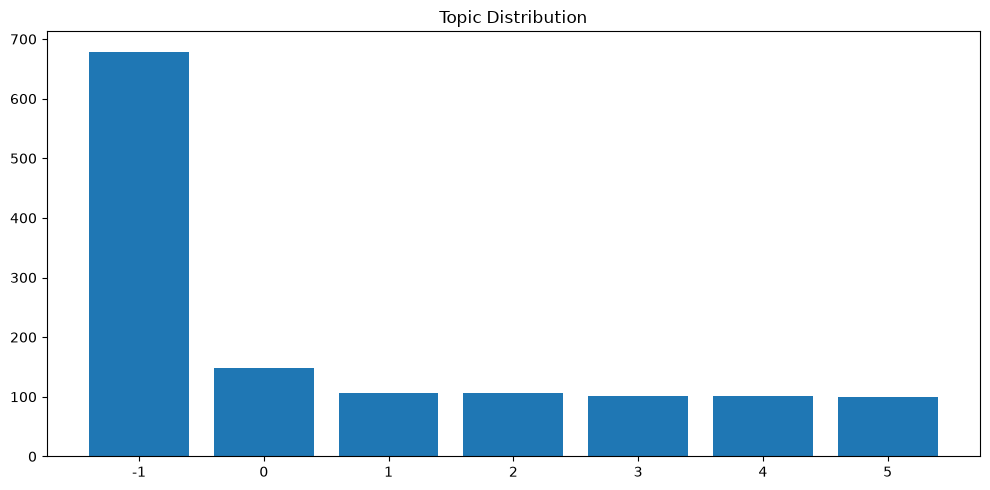

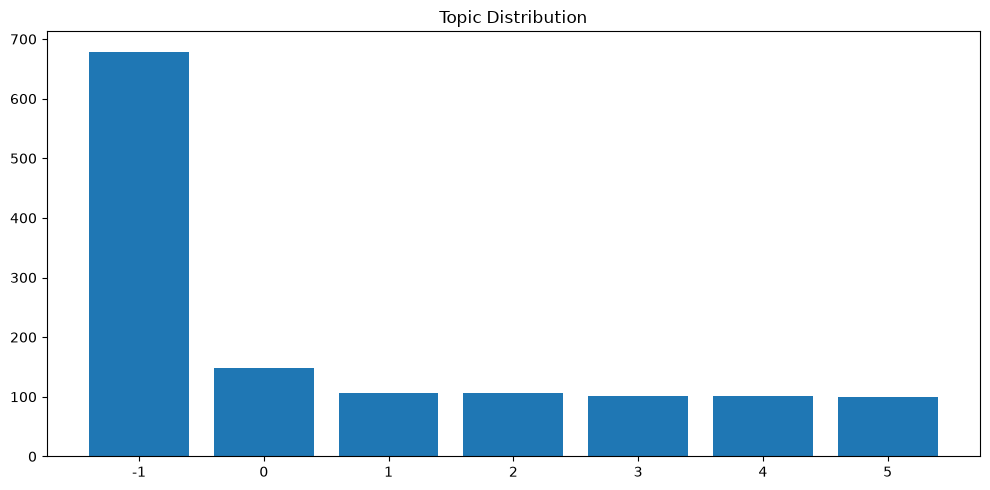

In [15]:
fig = plot_topic_distribution(topic_info)

fig

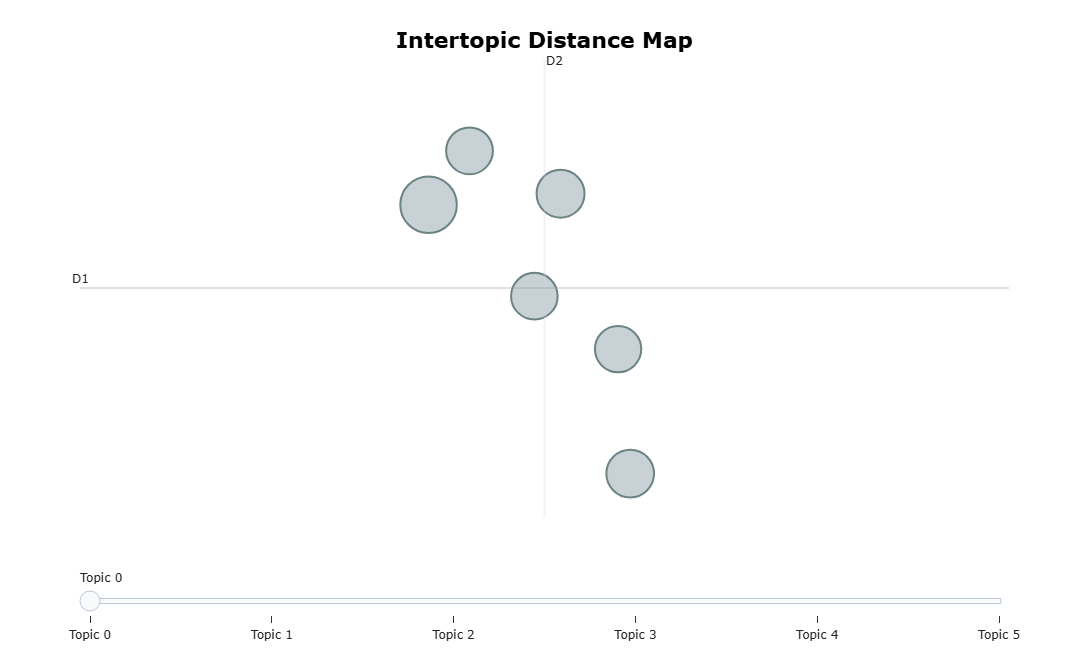

In [16]:
topic_model.visualize_topics()

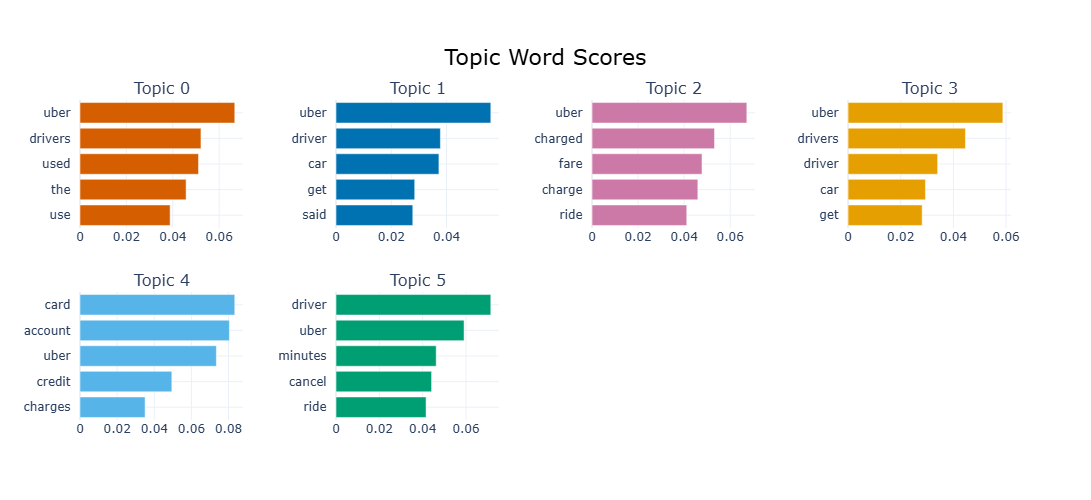

In [17]:
topic_model.visualize_barchart()

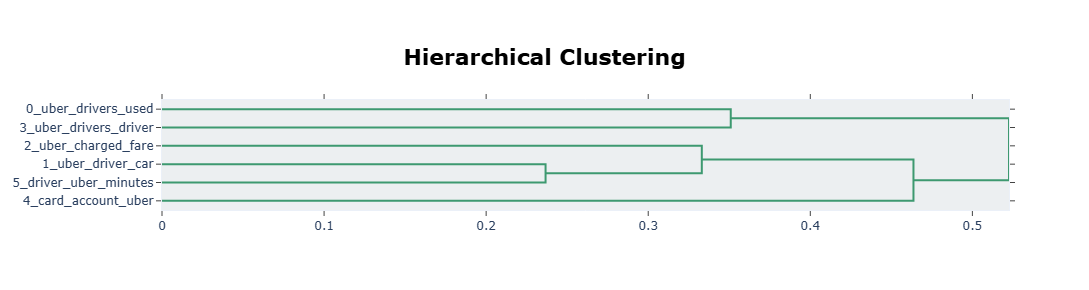

In [18]:
topic_model.visualize_hierarchy()

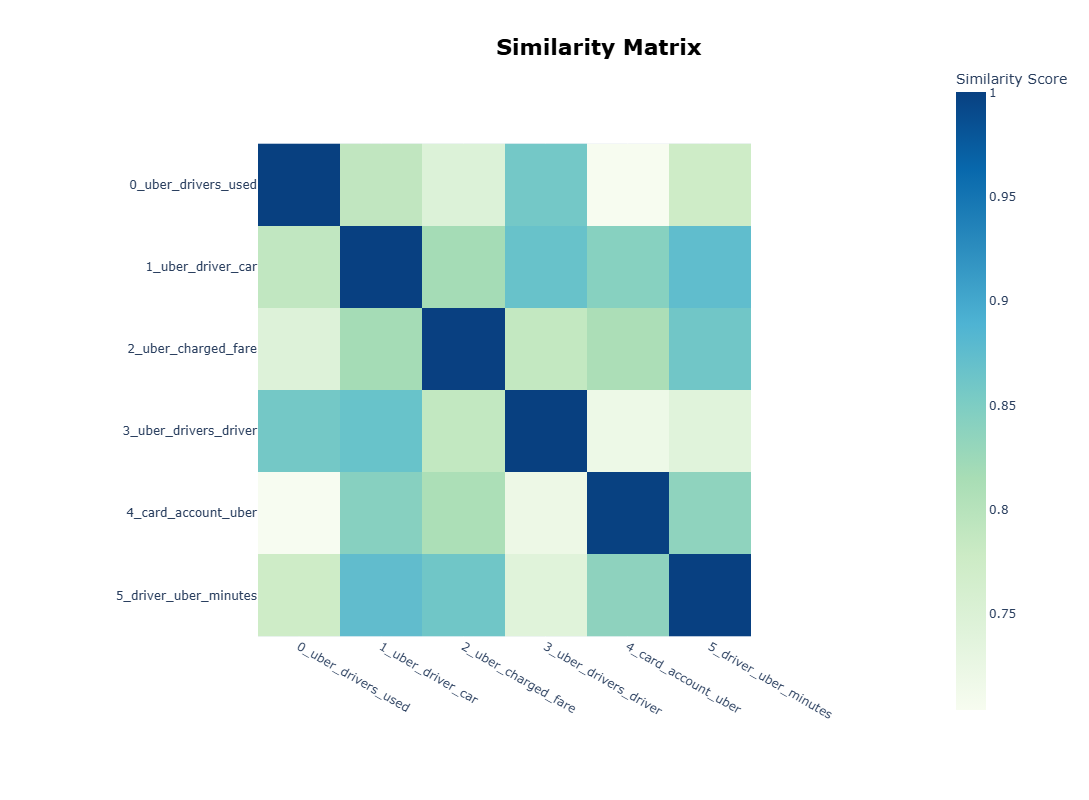

In [19]:
topic_model.visualize_heatmap()

### Documents by Topic

In [ ]:
topic_model.visualize_documents(df["clean_text"])

## Save Dataset

In [ ]:
save_processed_feedback(df, "feedback_with_topics.csv")

In [ ]:
save_processed_feedback(topic_info, "topic_summary.csv")

In [ ]:
save_topic_model(topic_model, MODEL_DIR / "topic_model")